In [29]:

import os
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects

plt.style.use('./main_theme.mplstyle')

wrk_dir = os.getcwd().removesuffix('experimental_scripts')


In [11]:

df_2500m = pd.read_csv(wrk_dir + '/dataset/FIRMS_2000-2025_2500m.csv')
df_5000m = pd.read_csv(wrk_dir + '/dataset/FIRMS_2000-2025_5000m.csv')

def df_to_gdf(df):
    try:
        df = df[['FIAT_lat', 'FIAT_lon', 'confidence']]
        df = df.rename(columns={'FIAT_lat': 'LAT', 'FIAT_lon': 'LON'})

        df = df[df['confidence'] >= 80]
        gdf = gpd.GeoDataFrame(
            df,
            geometry=gpd.points_from_xy(df.FIAT_lon, df.FIAT_lat),
            crs="EPSG:4326"
        )
        return gdf
    except:
        df = df[['LAT', 'LON', 'confidence']]

        df = df[df['confidence'] >= 80]

        gdf = gpd.GeoDataFrame(
            df,
            geometry=gpd.points_from_xy(df.LON, df.LAT),
            crs="EPSG:4326"
        )
        return gdf

gdf_2500m = df_to_gdf(df_2500m)
gdf_5000m = df_to_gdf(df_5000m)


/tmp/ipykernel_6901/69923353.py:2: DtypeWarning: Columns (0: EVI_10A_DATE, 1: EVI_9A_DATE, 2: FPAR_10A_DATE, 3: LAI_10A_DATE, 4: NDVI_10A_DATE, 5: NDVI_9A_DATE, 6: REFL_10A_DATE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_5000m = pd.read_csv(wrk_dir + '/dataset/FIRMS_2000-2025_5000m.csv')


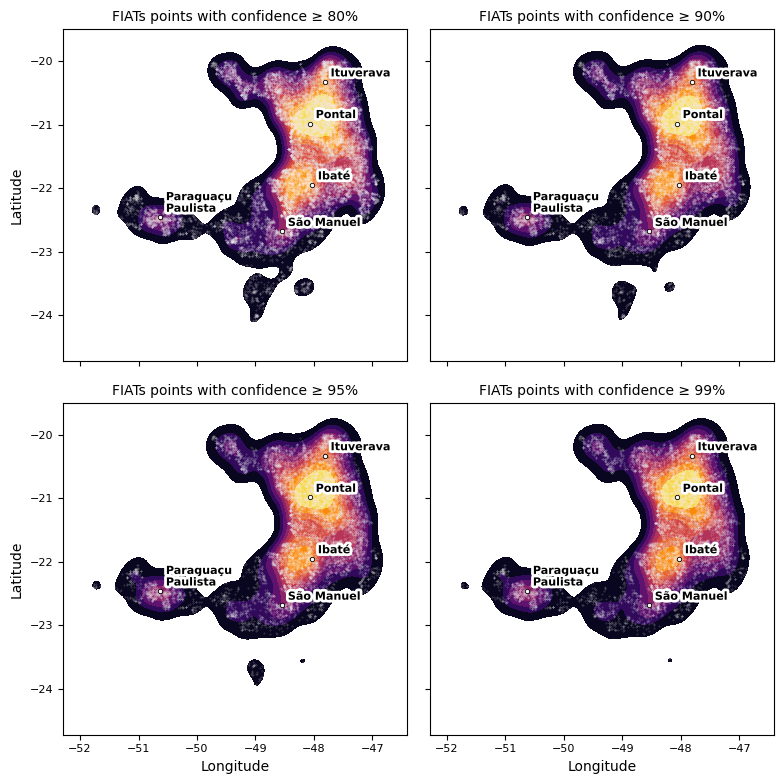

In [46]:

municipialities_SP = gpd.read_file(wrk_dir + 'IBGE_shapefiles/Municipios_centroids/Municipios_centroids.shp')

TARGET_MUNICIPALITIES = [
    "Pontal",
    "Ibaté",
    "São Manuel",
    "Pintagueiras",
    "Ituverava",
    "Paraguaçu Paulista"
]

municipialities_SP = municipialities_SP[municipialities_SP["NM_MUN"].isin(TARGET_MUNICIPALITIES)]

def plot_kde_map(confidence_list: list, gdf: object, save_result: bool):

    fig, axs = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=True)
    axes = axs.flat

    for ax, confidence in zip(axes, confidence_list):
        # Filter the GeoDataFrame
        subset = gdf[gdf['confidence'] >= confidence]

        # Plot the KDE (Density)
        sns.kdeplot(
            x=subset.geometry.x, # Using geometry directly is safer for GeoDataFrames
            y=subset.geometry.y,
            fill=True,
            levels=10,
            cmap="inferno",
            ax=ax
        )

        # Plot the actual points on top
        subset.plot(markersize=0.1, color='white', alpha=0.1, ax=ax)

        municipialities_SP.plot(
            ax=ax,
            markersize=10,
            color="white",
            edgecolor="black",
            linewidth=0.6,
            zorder=5
        )
        
        for _, row in municipialities_SP.iterrows():
            if row["NM_MUN"] == "Paraguaçu Paulista":
                    ax.annotate(
                    "Paraguaçu\nPaulista",
                    xy=(row.geometry.x, row.geometry.y),
                    xytext=(4, 4),
                    textcoords="offset points",
                    fontsize=8,
                    color="black",
                    fontweight="bold",
                    path_effects=[PathEffects.withStroke(linewidth=4, foreground="white")]
                )
            else:
                ax.annotate(
                    row["NM_MUN"],
                    xy=(row.geometry.x, row.geometry.y),
                    xytext=(4, 4),
                    textcoords="offset points",
                    fontsize=8,
                    color="black",
                    fontweight="bold",
                    path_effects=[PathEffects.withStroke(linewidth=4, foreground="white")]
                )

        ax.set_title(f"FIATs points with confidence ≥ {confidence}%")

        # Ensure the map isn't stretched
        ax.set_aspect('equal')
        ax.axis('tight')
        ax.set_ylabel("Latitude")
        ax.set_xlabel("Longitude")

    plt.tight_layout()

    if save_result == True:
        plt.savefig(wrk_dir + f"/figures/KDE_plot-{confidence_list[0]}_{confidence_list[1]}_{confidence_list[2]}_{confidence_list[3]}.png", dpi=600)
        plt.show()
    else:
        plt.show()

plot_kde_map(
    confidence_list=[80, 90, 95, 99], 
    gdf=gdf_2500m, 
    save_result=True)
